In [131]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import RFE, SelectKBest, f_classif, mutual_info_classif, mutual_info_regression,f_regression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier ,GradientBoostingRegressor,IsolationForest
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso
import xgboost as xgb
import plotly.graph_objects as go
import plotly.express as px

In [132]:
# ------------------------------
# 1. Load Data, Drop COVID Anomaly & Engineer Targets
# ------------------------------
df = pd.read_csv('cleaned_new_data.csv')

# Drop COVID anomaly year only (keep 2026 — used as test boundary)
df = df[df['Year'] != 2021].reset_index(drop=True)

repetition_cols = [f'g{i}_repetition' for i in range(1, 13)]
df['avg_repetition_rate'] = df[repetition_cols].mean(axis=1)

dropout_cols = [f'g{i}_dropout' for i in range(1, 13)]
df['avg_dropout_rate'] = df[dropout_cols].mean(axis=1)
overage_cols = ["pct_overage_enrollment_primary", "pct_overage_enrollment_lower_sec", "pct_overage_enrollment_upper_sec"]
df["over_age_enrollment_total"]=df[overage_cols].sum(axis = 1)
df['kids_population']=df[["pop_aged6_total","pop_aged6_11_total","pop_aged12_14_total","pop_aged15_17_total"]].sum(axis=1)
df['bad_qual_teacher']= df[["teaching_staff_edu_primary","teaching_staff_edu_lower_sec","teaching_staff_edu_upper_sec"]].sum(axis=1)
df['good_qual_teacher']= df[["teaching_staff_edu_graduate","teaching_staff_edu_postgrad","teaching_staff_edu_phd"]].sum(axis=1)
# avg_promotion_rate removed — unused downstream


In [133]:
# ------------------------------
# 2. Staff Qualification Feature Engineering
# ------------------------------
edu_levels = ["primary", "lower_sec", "upper_sec", "graduate", "postgrad", "phd"]
weights = {"primary": 1, "lower_sec": 2, "upper_sec": 3, "graduate": 4, "postgrad": 5, "phd": 6}

# No-pedagogy ratio
df["no_pedagogy_ratio"] = (
    df[[f"teaching_staff_no_pedagogy_{l}" for l in edu_levels]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)

# High/low qual ratio (teaching staff)
df["teaching_high_qual_ratio"] = (
    df[[f"teaching_staff_edu_{l}" for l in ["graduate", "postgrad", "phd"]]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)
df["teaching_low_qual_ratio"] = (
    df[[f"teaching_staff_edu_{l}" for l in ["primary", "lower_sec", "upper_sec"]]].sum(axis=1)
    / df["teaching_staff_total"].replace(0, pd.NA)
)

# Qualification index per staff group
for prefix in ["teaching_staff_edu", "non_teaching_staff_edu", "teaching_staff_no_pedagogy"]:
    weighted_sum = sum(df[f"{prefix}_{level}"] * w for level, w in weights.items())
    total = df[[f"{prefix}_{level}" for level in edu_levels]].sum(axis=1).replace(0, pd.NA)
    df[f"{prefix}_qual_index"] = weighted_sum / total


In [134]:
df['bad_qual_teacher']= df[["teaching_staff_edu_primary","teaching_staff_edu_lower_sec","teaching_staff_edu_upper_sec"]].sum(axis=1)
df['good_qual_teacher']= df[["teaching_staff_edu_graduate","teaching_staff_edu_postgrad","teaching_staff_edu_phd"]].sum(axis=1)
    

In [135]:
features_list_enrollment = [
    "Province","Year",
    "enrollment_total",
    "classroom_area_per_student",
    "wooden_rooms",
    "pb_fund_per_school_riel",
    "bamboo_buildings",
    "pct_schools_two_shift",
    "bamboo_rooms",
    "pct_schools_in_pagoda",
    "pupil_teacher_ratio",
    "funding_community",
    "pupil_classroom_ratio",
    "schools_with_library",
    "bad_qual_teacher",
    "total_staff_total",
    "kids_population",
    "num_classrooms",
]

drop_out_features = [
    "Province","Year",
    "avg_dropout_rate",
    "pct_schools_in_pagoda",
    "principal_avg_service_years",
    "good_qual_teacher",
    "pb_fund_per_school_riel",
    "total_staff_total",
    "bad_qual_teacher",
    "kids_population",
    "num_classrooms",
    "schools_with_library",
    "schools_with_office",
    "pct_schools_two_shift",
    "pct_overage_enrollment_lower_sec",
    "pupil_teacher_ratio",
    "pct_overage_enrollment_primary",
    "wooden_rooms",
]

teacher_quality_features = [
    "Province","Year",
    "teaching_staff_edu_qual_index",
    "classroom_area_per_student",
    "wooden_rooms",
    "pct_schools_two_shift",
    "pupil_teacher_ratio",
    "bamboo_buildings",
    "bamboo_rooms",
    "funding_abroad",
    "schools_without_water",
    "pb_fund_per_school_riel",
    "funding_ios_ngos",
    "num_classrooms",
    "schools_with_office",
    "schools_with_library",
    "pct_schools_in_pagoda",
    "preschool_with_sport_facility",
]

In [136]:
def corr_heatmap(df, target, feature_cols, title):
    cols = [c for c in feature_cols if c in df.columns and c != target]
    corr = df[cols + [target]].corr()[[target]].drop(target)
    corr.columns = ["correlation"]

    # Get the 5 largest positive and 5 largest negative correlations
    top_positive = corr.nlargest(5, "correlation")
    top_negative = corr.nsmallest(10, "correlation")

    # Combine and sort them
    corr = (
        pd.concat([top_negative, top_positive])
        .drop_duplicates()
        .sort_values("correlation")
    )

    fig = px.imshow(
        corr,
        color_continuous_scale="RdBu_r",
        zmin=-1,
        zmax=1,
        aspect="auto",
        text_auto=".2f",
        title=title,
    )
    fig.update_layout(
        height=max(300, len(corr) * 44),
        coloraxis_colorbar=dict(title="r"),
    )

    fig.show()


def plot_features_grid(df, features, target):
    # Ensure column names match lowercase
    df.columns = [c.lower() for c in df.columns]
    features = [f.lower() for f in features]
    target = target.lower()

    # --- Apply Dark Theme Styling ---
    plt.style.use("dark_background")

    rc_params = {
        "figure.facecolor": "#11141a",
        "axes.facecolor": "#11141a",
        "axes.edgecolor": "#31333f",
        "grid.color": "#31333f",
        "text.color": "#ffffff",
        "axes.labelcolor": "#a3a8b4",
        "xtick.color": "#a3a8b4",
        "ytick.color": "#a3a8b4",
    }
    plt.rcParams.update(rc_params)

    # Setup the 5x3 grid
    fig, axes = plt.subplots(5, 3, figsize=(20, 25))
    fig.suptitle(
        f"Features vs {target.replace('_', ' ').title()}",
        fontsize=22,
        color="#ffffff",
        weight="bold",
    )

    # Vibrant neon/pastel palette
    colors = sns.color_palette("coolwarm", len(features))

    # Loop through features and populate the subplots dynamically
    for i, feature in enumerate(features):
        row = i // 3
        col = i % 3
        ax = axes[row, col]

        if feature in df.columns:
            sns.regplot(
                data=df,
                x=feature,
                y=target,
                ax=ax,
                scatter_kws={"alpha": 0.6, "color": colors[i], "s": 40},
                line_kws={"color": "#ff4b4b", "linewidth": 2},
            )
            ax.set_title(feature, fontsize=12, color="#ffffff", pad=10)
            ax.set_xlabel(feature, fontsize=10)
            ax.set_ylabel(target, fontsize=10)
            ax.grid(True, linestyle="--", alpha=0.1)
        else:
            ax.text(
                0.5,
                0.5,
                f"Feature '{feature}'\nnot found",
                ha="center",
                va="center",
                fontsize=12,
                color="#ff4b4b",
            )
            ax.axis("off")

    # Adjust layout for neat spacing
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
def plot_timeseries_grid(df, features, time_col="year"):
    # Apply clean dark styling
    plt.style.use("dark_background")

    # Setup 3 rows by 5 columns grid
    fig, axes = plt.subplots(3, 5, figsize=(22, 12))
    axes = axes.flatten()  # Flatten to easily loop over 15 slots

    for i, feature in enumerate(features):
        ax = axes[i]
        if feature in df.columns:
            # sns.lineplot automatically aggregates multiple rows per year (e.g. provinces)
            sns.lineplot(
                data=df,
                x=time_col,
                y=feature,
                ax=ax,
                marker="o",
                linewidth=2,
                color="#00d2ff",
            )
            ax.set_title(feature.replace("_", " ").title(), fontsize=10)
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.grid(True, linestyle="--", alpha=0.2)
        else:
            ax.axis("off")  # Hide empty subplots if feature is missing

    plt.tight_layout()
    plt.show()

In [137]:
enroll = df[features_list_enrollment]
drop_out = df[drop_out_features]
teacher = df[teacher_quality_features]

In [138]:
def remove_outliers_iforest(df, contamination=0.05):
    numeric_df = df.select_dtypes(include=["number"]).dropna()

    iso = IsolationForest(contamination=contamination, random_state=42)
    preds = iso.fit_predict(numeric_df)

    valid_indices = numeric_df.index[preds == 1]
    yeeted_indices = numeric_df.index[preds == -1]

    print(f"=== YEETED {len(yeeted_indices)} ROWS VIA ISOLATION FOREST ===")
    if not yeeted_indices.empty:
        with pd.option_context(
            "display.max_columns", None, "display.width", 1000
        ):
            print(df.loc[yeeted_indices])
    print("==================================================\n")

    return df.loc[valid_indices].copy()

Isolation Forest isolates outliers by drawing random lines to split your data.

* Normal rows are clustered tightly together, so it takes many splits to isolate them.

* Outliers sit far away from the crowd, so it takes very few splits to isolate them.

It catches relationship anomalies (like a school with 2 classrooms but 1,000 students) because that specific combination sits in a lonely, empty space, causing the algorithm to cut it away from the rest of the data almost instantly.

In [139]:
enroll = remove_outliers_iforest(enroll)

=== YEETED 13 ROWS VIA ISOLATION FOREST ===
       Province  Year  enrollment_total  classroom_area_per_student  wooden_rooms  pb_fund_per_school_riel  bamboo_buildings  pct_schools_two_shift  bamboo_rooms  pct_schools_in_pagoda  pupil_teacher_ratio  funding_community  pupil_classroom_ratio  schools_with_library  bad_qual_teacher  total_staff_total  kids_population  num_classrooms
1    Battambang  2016          233906.0                        1.30        1435.0                3629355.0              19.0                   53.9          48.0                   24.9                 34.6              100.0                   46.1                 328.0            5350.0             8593.0         346260.0          5069.0
14   Phnom Penh  2016          229987.0                        1.00          36.0                7503963.0               0.0                   48.0           0.0                   50.9                 22.9               95.0                   61.7                 220.0       

In [140]:
drop_out = remove_outliers_iforest(drop_out)

=== YEETED 13 ROWS VIA ISOLATION FOREST ===
         Province  Year  avg_dropout_rate  pct_schools_in_pagoda  principal_avg_service_years  good_qual_teacher  pb_fund_per_school_riel  total_staff_total  bad_qual_teacher  kids_population  num_classrooms  schools_with_library  schools_with_office  pct_schools_two_shift  pct_overage_enrollment_lower_sec  pupil_teacher_ratio  pct_overage_enrollment_primary  wooden_rooms
1      Battambang  2016         17.308333                   24.9                         21.2             1414.0                3629355.0             8593.0            5350.0         346260.0          5069.0                 328.0                495.0                   53.9                              29.9                 34.6                            14.9        1435.0
8             Kep  2016         11.275000                   44.0                         20.8              153.0                3872228.0              566.0             318.0          14441.0           241.

In [141]:
teacher = remove_outliers_iforest(teacher)

=== YEETED 13 ROWS VIA ISOLATION FOREST ===
         Province  Year  teaching_staff_edu_qual_index  classroom_area_per_student  wooden_rooms  pct_schools_two_shift  pupil_teacher_ratio  bamboo_buildings  bamboo_rooms  funding_abroad  schools_without_water  pb_fund_per_school_riel  funding_ios_ngos  num_classrooms  schools_with_office  schools_with_library  pct_schools_in_pagoda  preschool_with_sport_facility
1      Battambang  2016                       2.957422                        1.30        1435.0                   53.9                 34.6              19.0          48.0            11.0                  713.0                3629355.0              20.0          5069.0                495.0                 328.0                   24.9                          244.0
17      Prey Veng  2016                       2.847782                        1.24         367.0                   46.8                 41.1               6.0           2.0             7.0                  423.0         

In [147]:
feature1 = [
    "classroom_area_per_student",
    "wooden_rooms",
    "pb_fund_per_school_riel",
    "bamboo_buildings",
    "pct_schools_two_shift",
    "bamboo_rooms",
    "pct_schools_in_pagoda",
    "pupil_teacher_ratio",
    "funding_community",
    "pupil_classroom_ratio",
    "schools_with_library",
    "bad_qual_teacher",
    "total_staff_total",
    "kids_population",
    "num_classrooms",
]

feature2 = [
    "avg_dropout_rate",
    "pct_schools_in_pagoda",
    "principal_avg_service_years",
    "good_qual_teacher",
    "pb_fund_per_school_riel",
    "total_staff_total",
    "bad_qual_teacher",
    "kids_population",
    "num_classrooms",
    "schools_with_library",
    "schools_with_office",
    "pct_schools_two_shift",
    "pct_overage_enrollment_lower_sec",
    "pupil_teacher_ratio",
    "pct_overage_enrollment_primary",
    "wooden_rooms",
]

feature3 = [
    "classroom_area_per_student",
    "wooden_rooms",
    "pct_schools_two_shift",
    "pupil_teacher_ratio",
    "bamboo_buildings",
    "bamboo_rooms",
    "funding_abroad",
    "schools_without_water",
    "pb_fund_per_school_riel",
    "funding_ios_ngos",
    "num_classrooms",
    "schools_with_office",
    "schools_with_library",
    "pct_schools_in_pagoda",
    "preschool_with_sport_facility",
]

In [143]:
corr_heatmap(enroll,"enrollment_total",feature1,'enrollment')

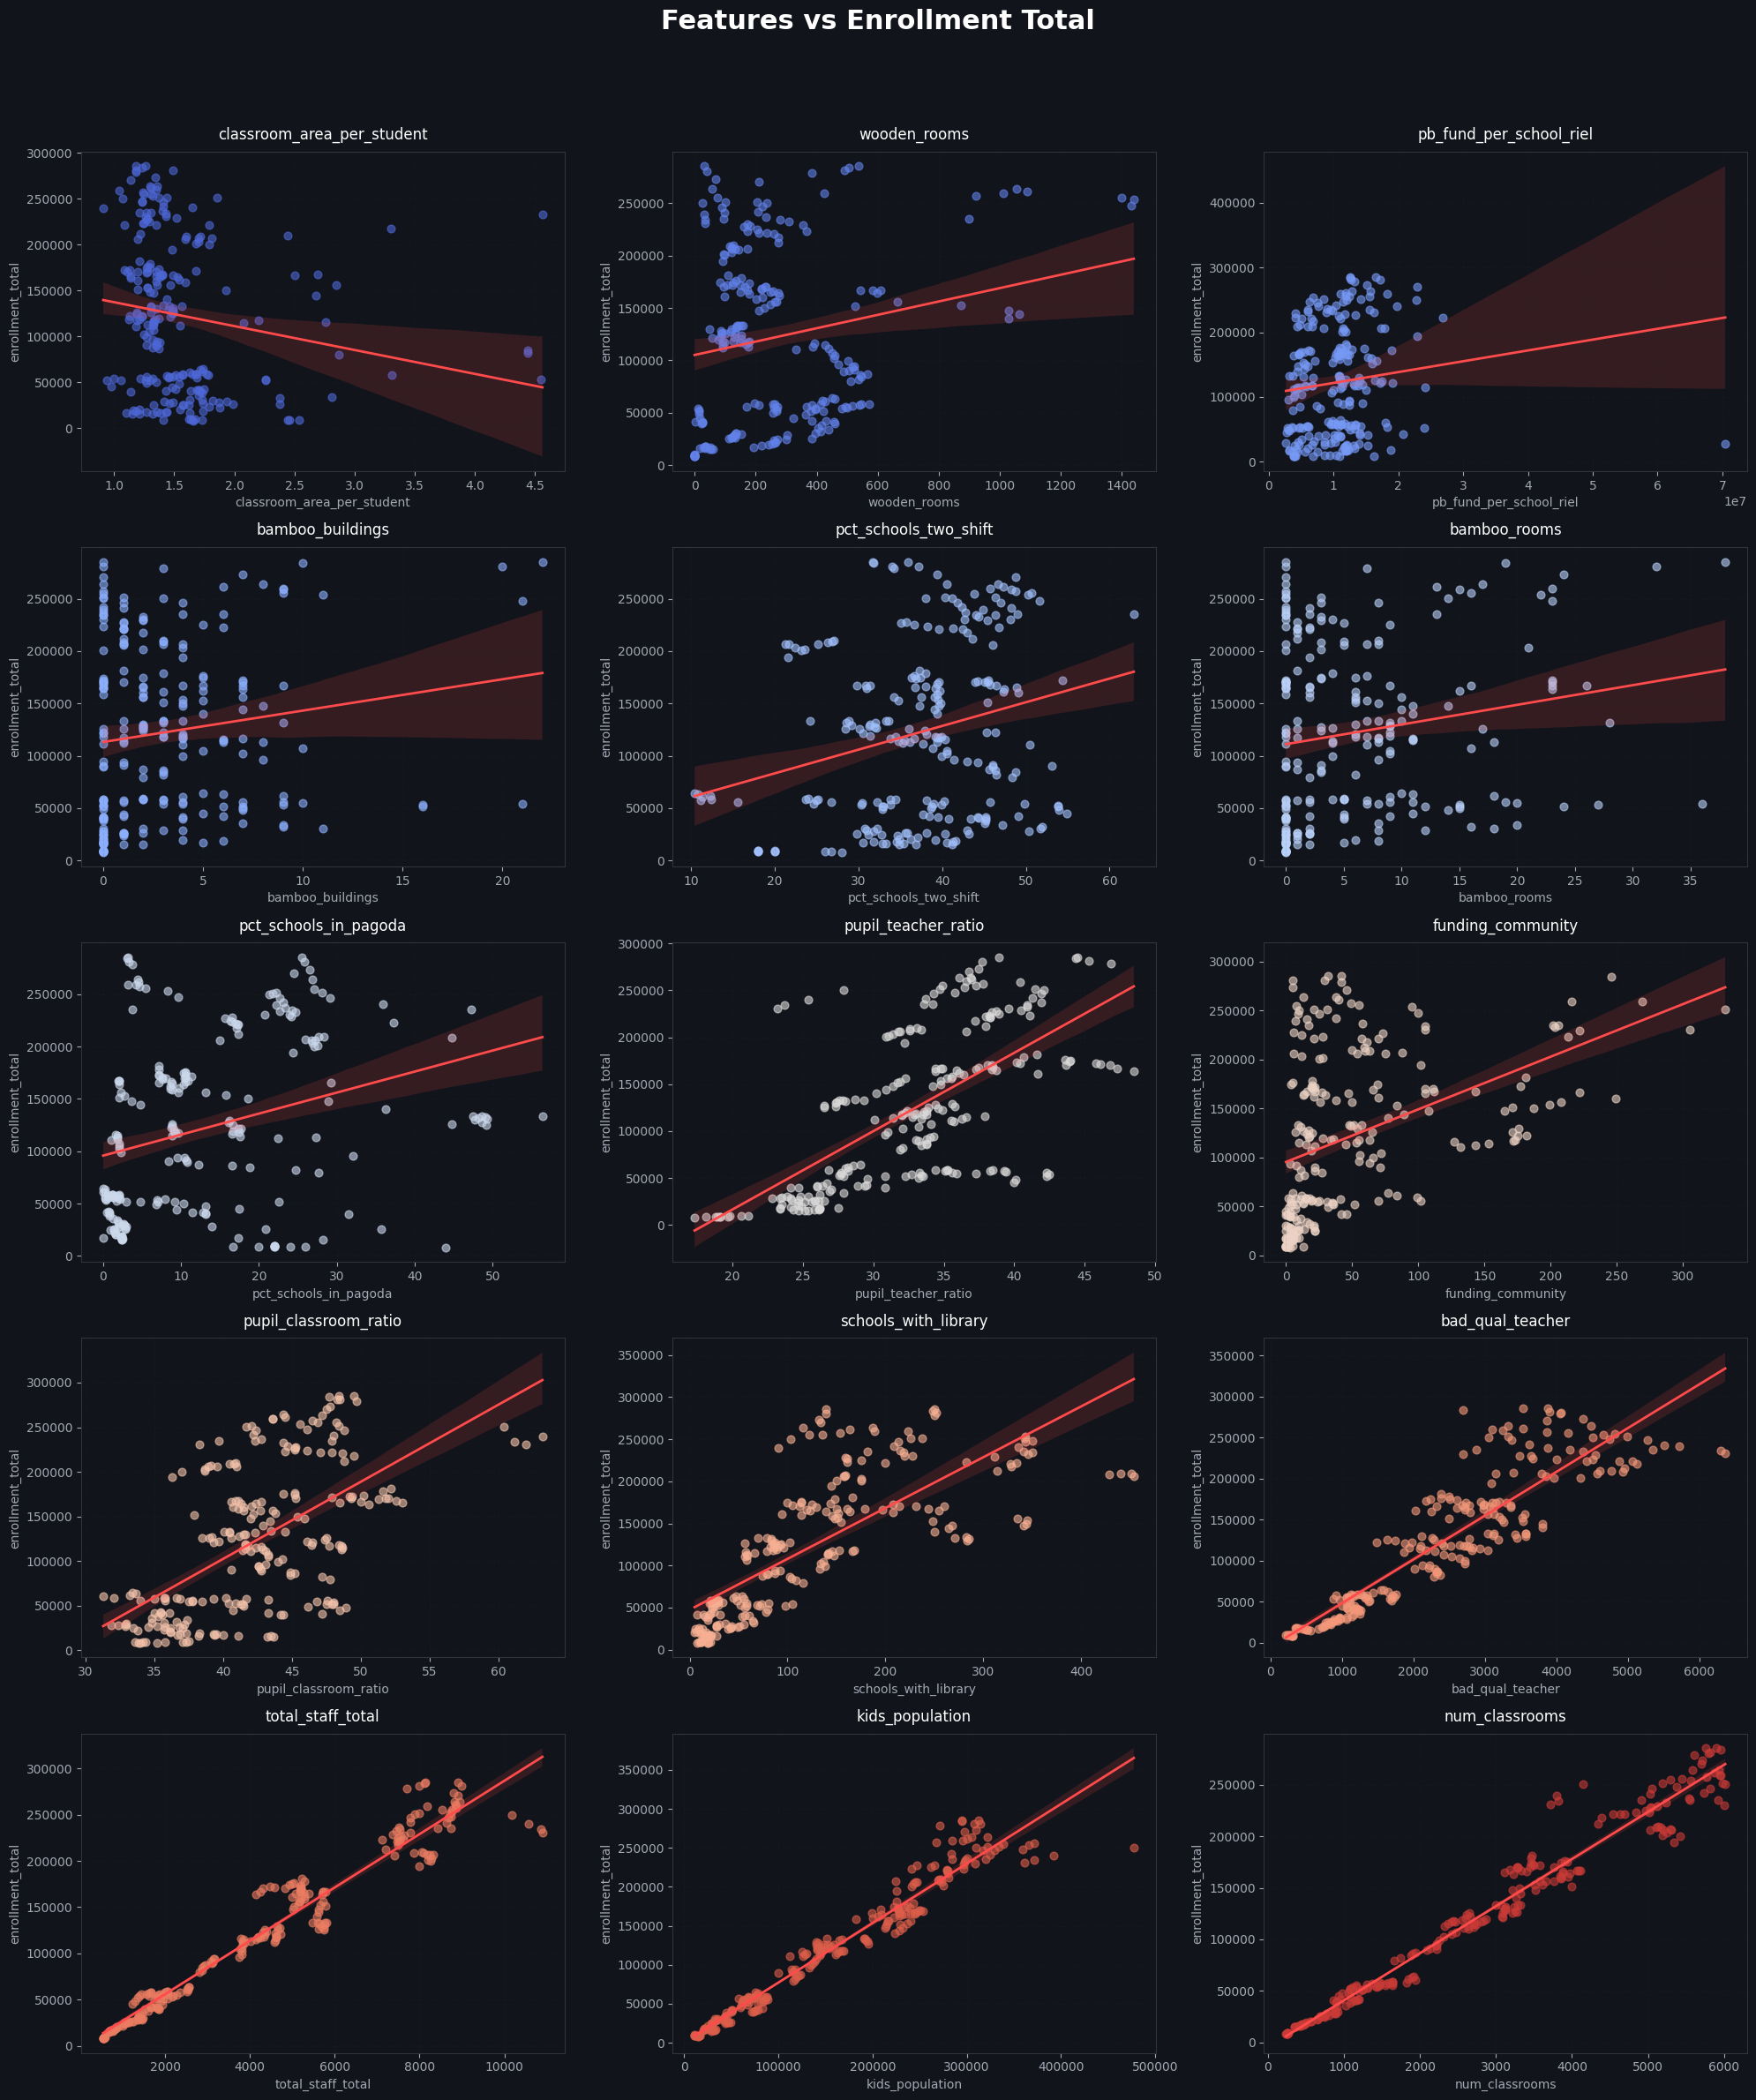

In [144]:
plot_features_grid(enroll,feature1,"enrollment_total")

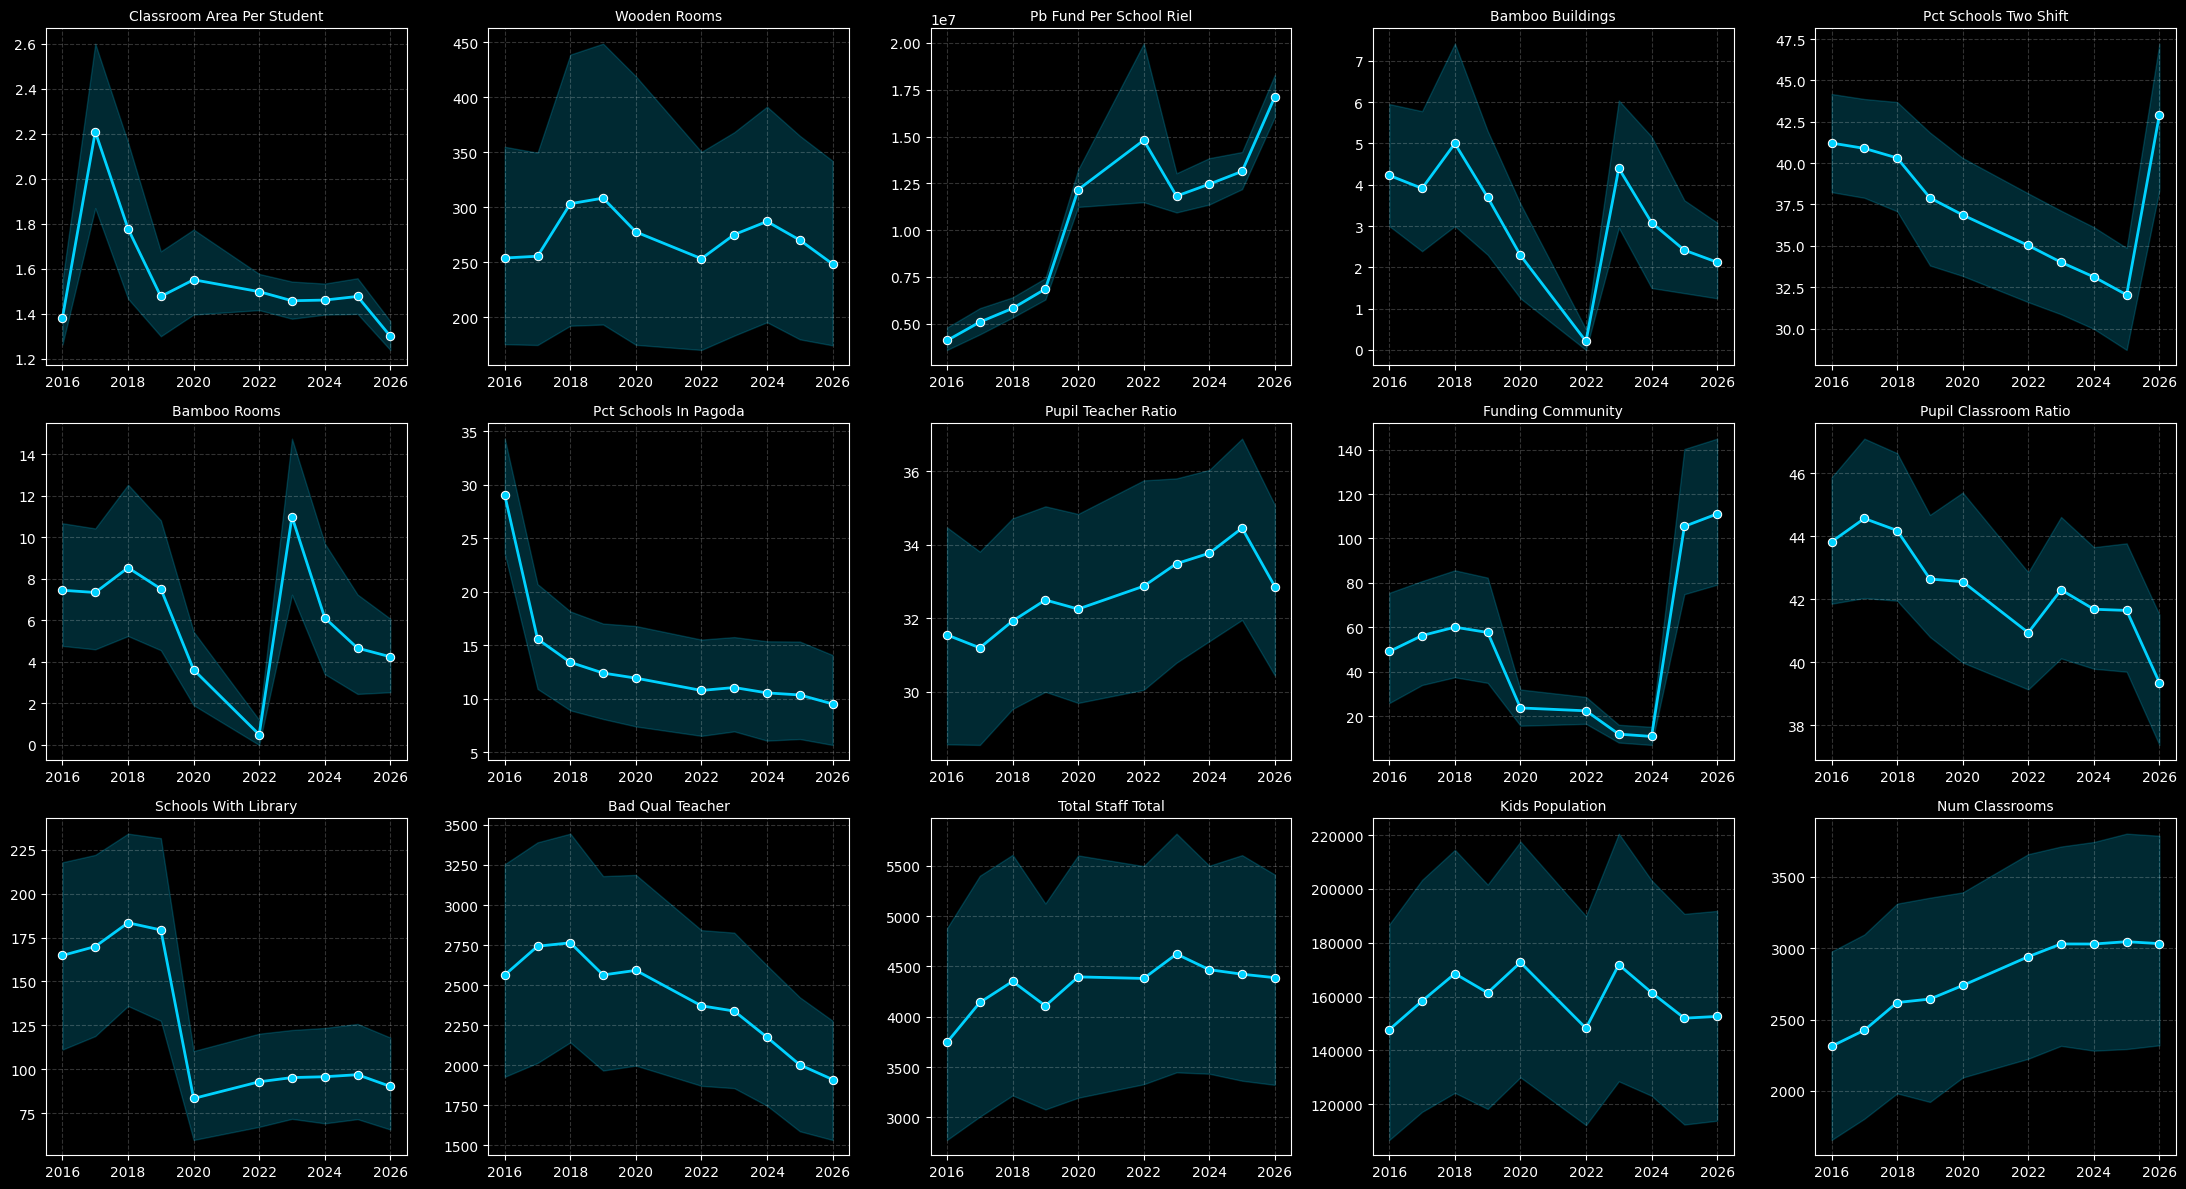

In [145]:
plot_timeseries_grid(enroll,feature1)

In [148]:
# 1. Correlation with targets
print("--- Correlation Matrix ---")
print(drop_out[feature2].corr()[['avg_dropout_rate']]) # Replace with your target names

# 2. Display feature names to check time-series characteristics
print("\n--- Available Features ---")
print(feature2)

--- Correlation Matrix ---
                                  avg_dropout_rate
avg_dropout_rate                          1.000000
pct_schools_in_pagoda                    -0.070435
principal_avg_service_years              -0.350681
good_qual_teacher                        -0.273772
pb_fund_per_school_riel                  -0.158694
total_staff_total                        -0.142795
bad_qual_teacher                         -0.012475
kids_population                          -0.070981
num_classrooms                           -0.118346
schools_with_library                     -0.052978
schools_with_office                      -0.037253
pct_schools_two_shift                     0.172672
pct_overage_enrollment_lower_sec          0.448876
pupil_teacher_ratio                       0.140595
pct_overage_enrollment_primary            0.179071
wooden_rooms                              0.223852

--- Available Features ---
['avg_dropout_rate', 'pct_schools_in_pagoda', 'principal_avg_service_years', '

In [ ]:
corr_heatmap(drop_out,"avg_dropout_rate",feature2,'drop_out')

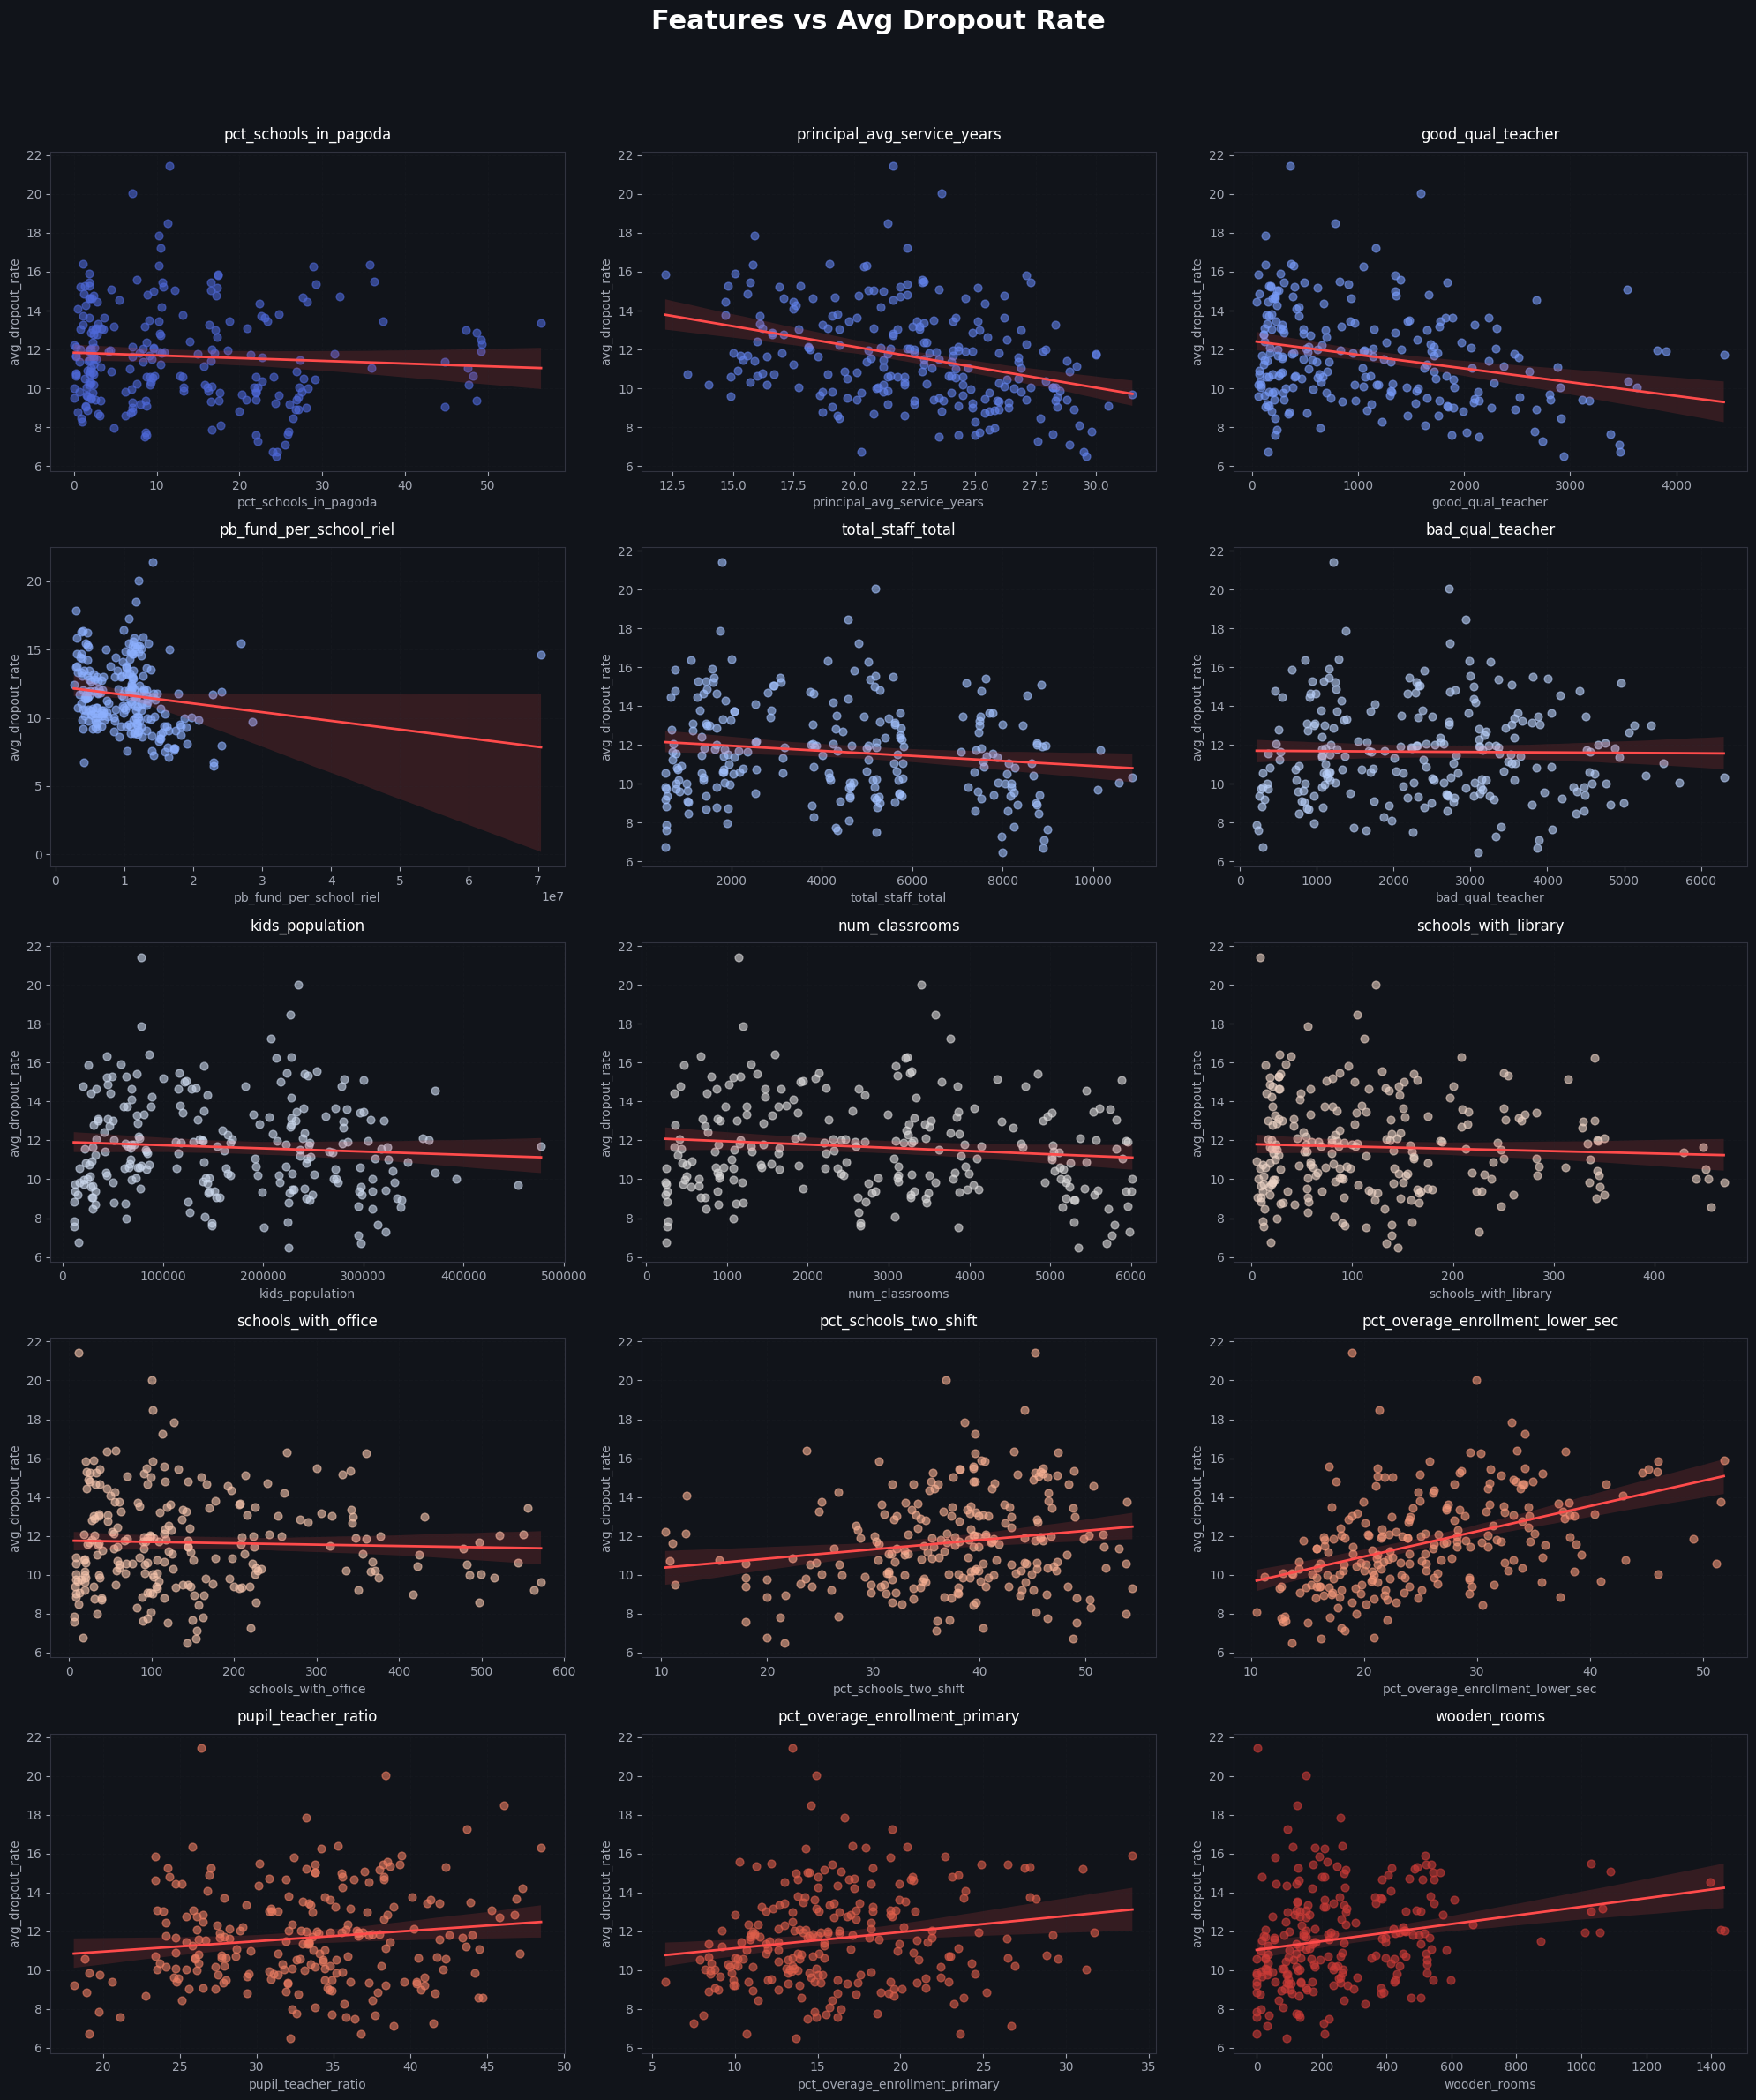

In [ ]:
plot_features_grid(drop_out,feature2,"avg_dropout_rate")

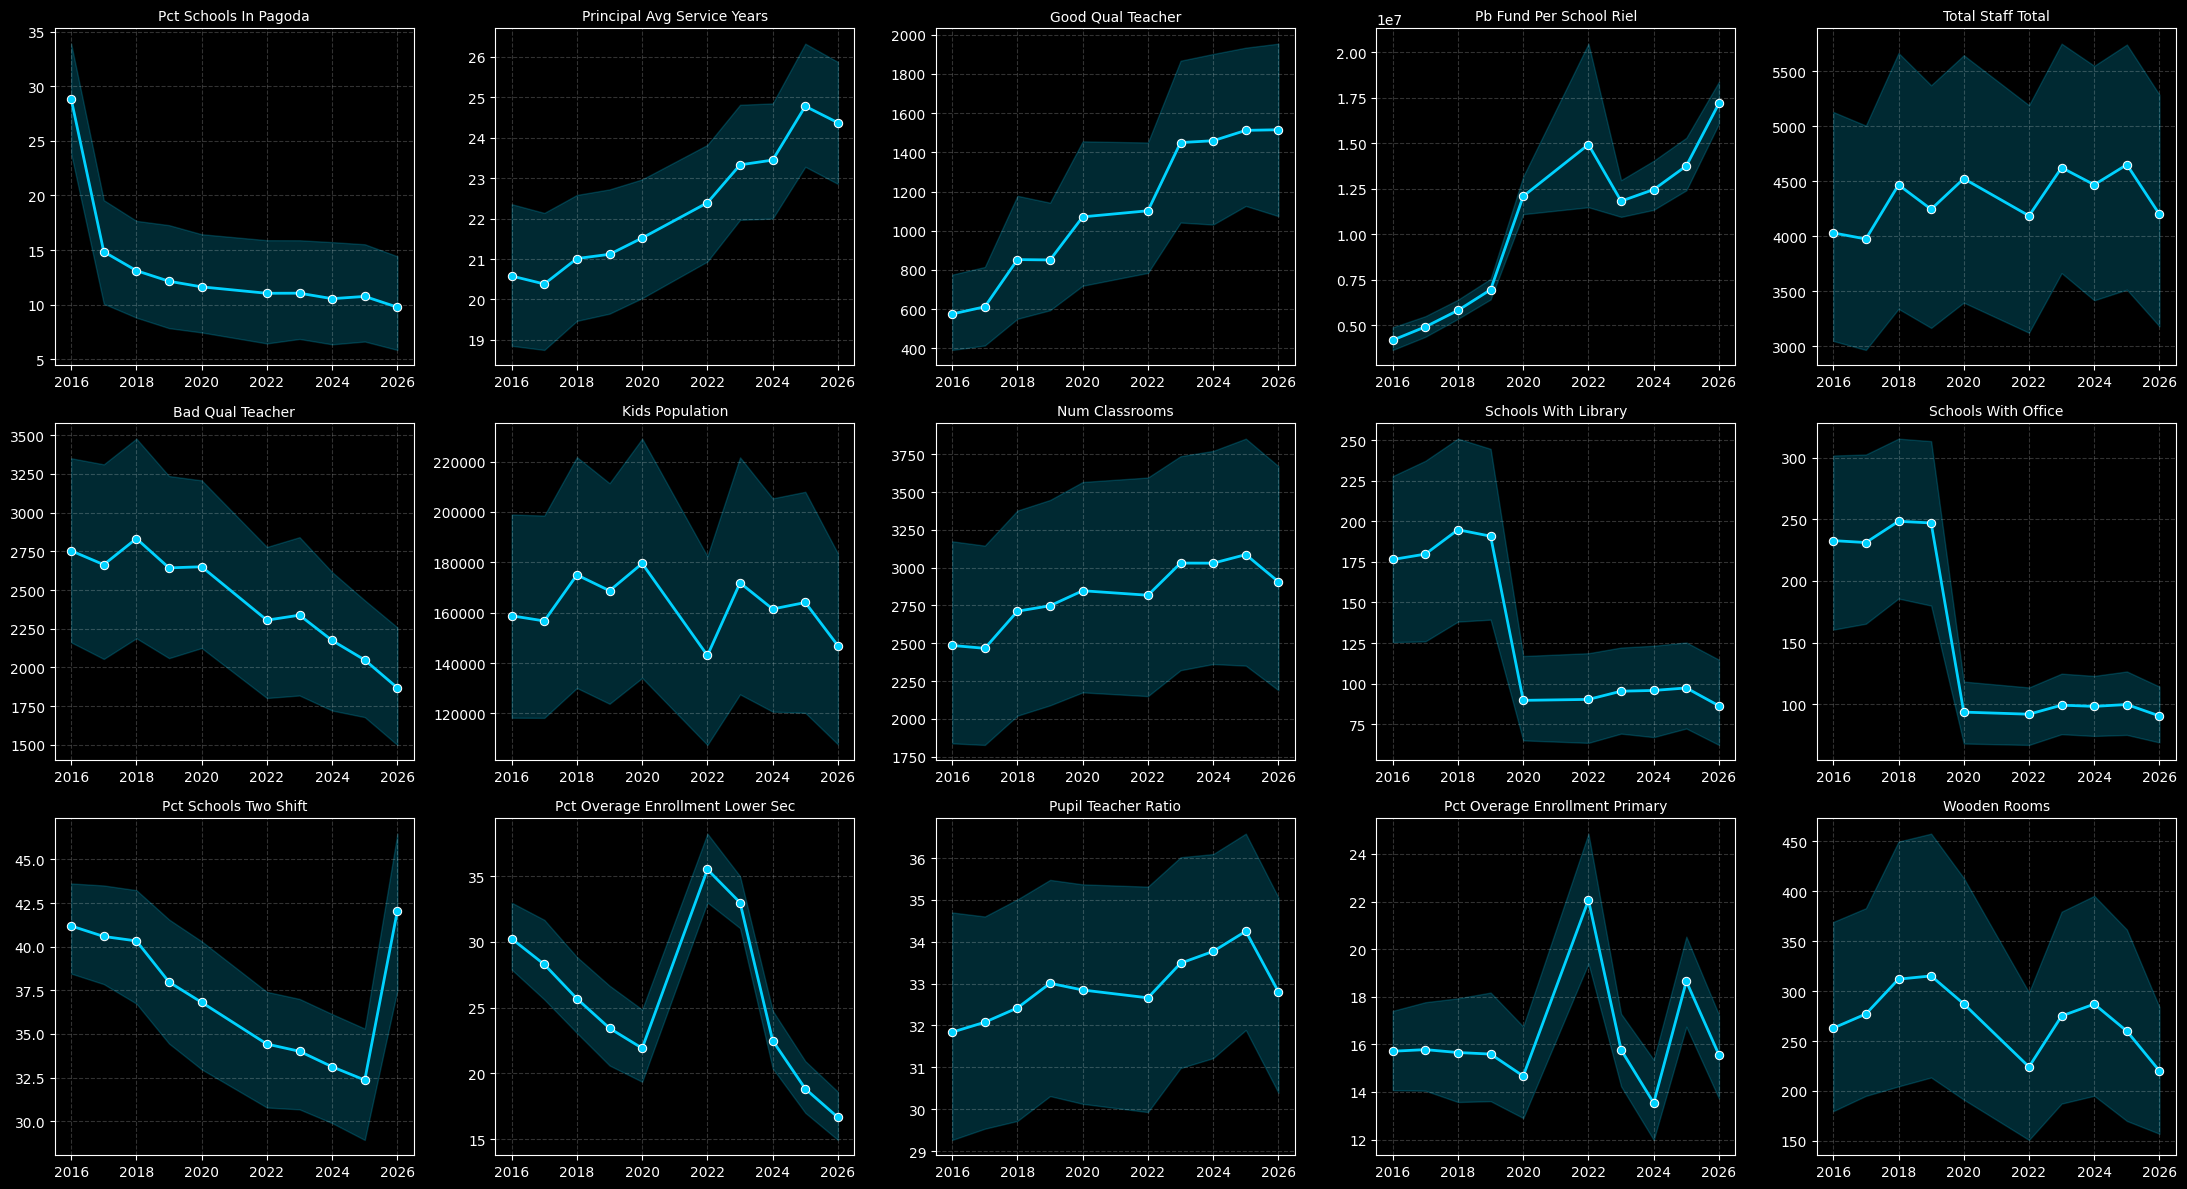

In [ ]:
plot_timeseries_grid(drop_out,feature2)

In [ ]:
corr_heatmap(teacher,"teaching_staff_edu_qual_index",feature3,'teaching_staff_edu_qual_index')

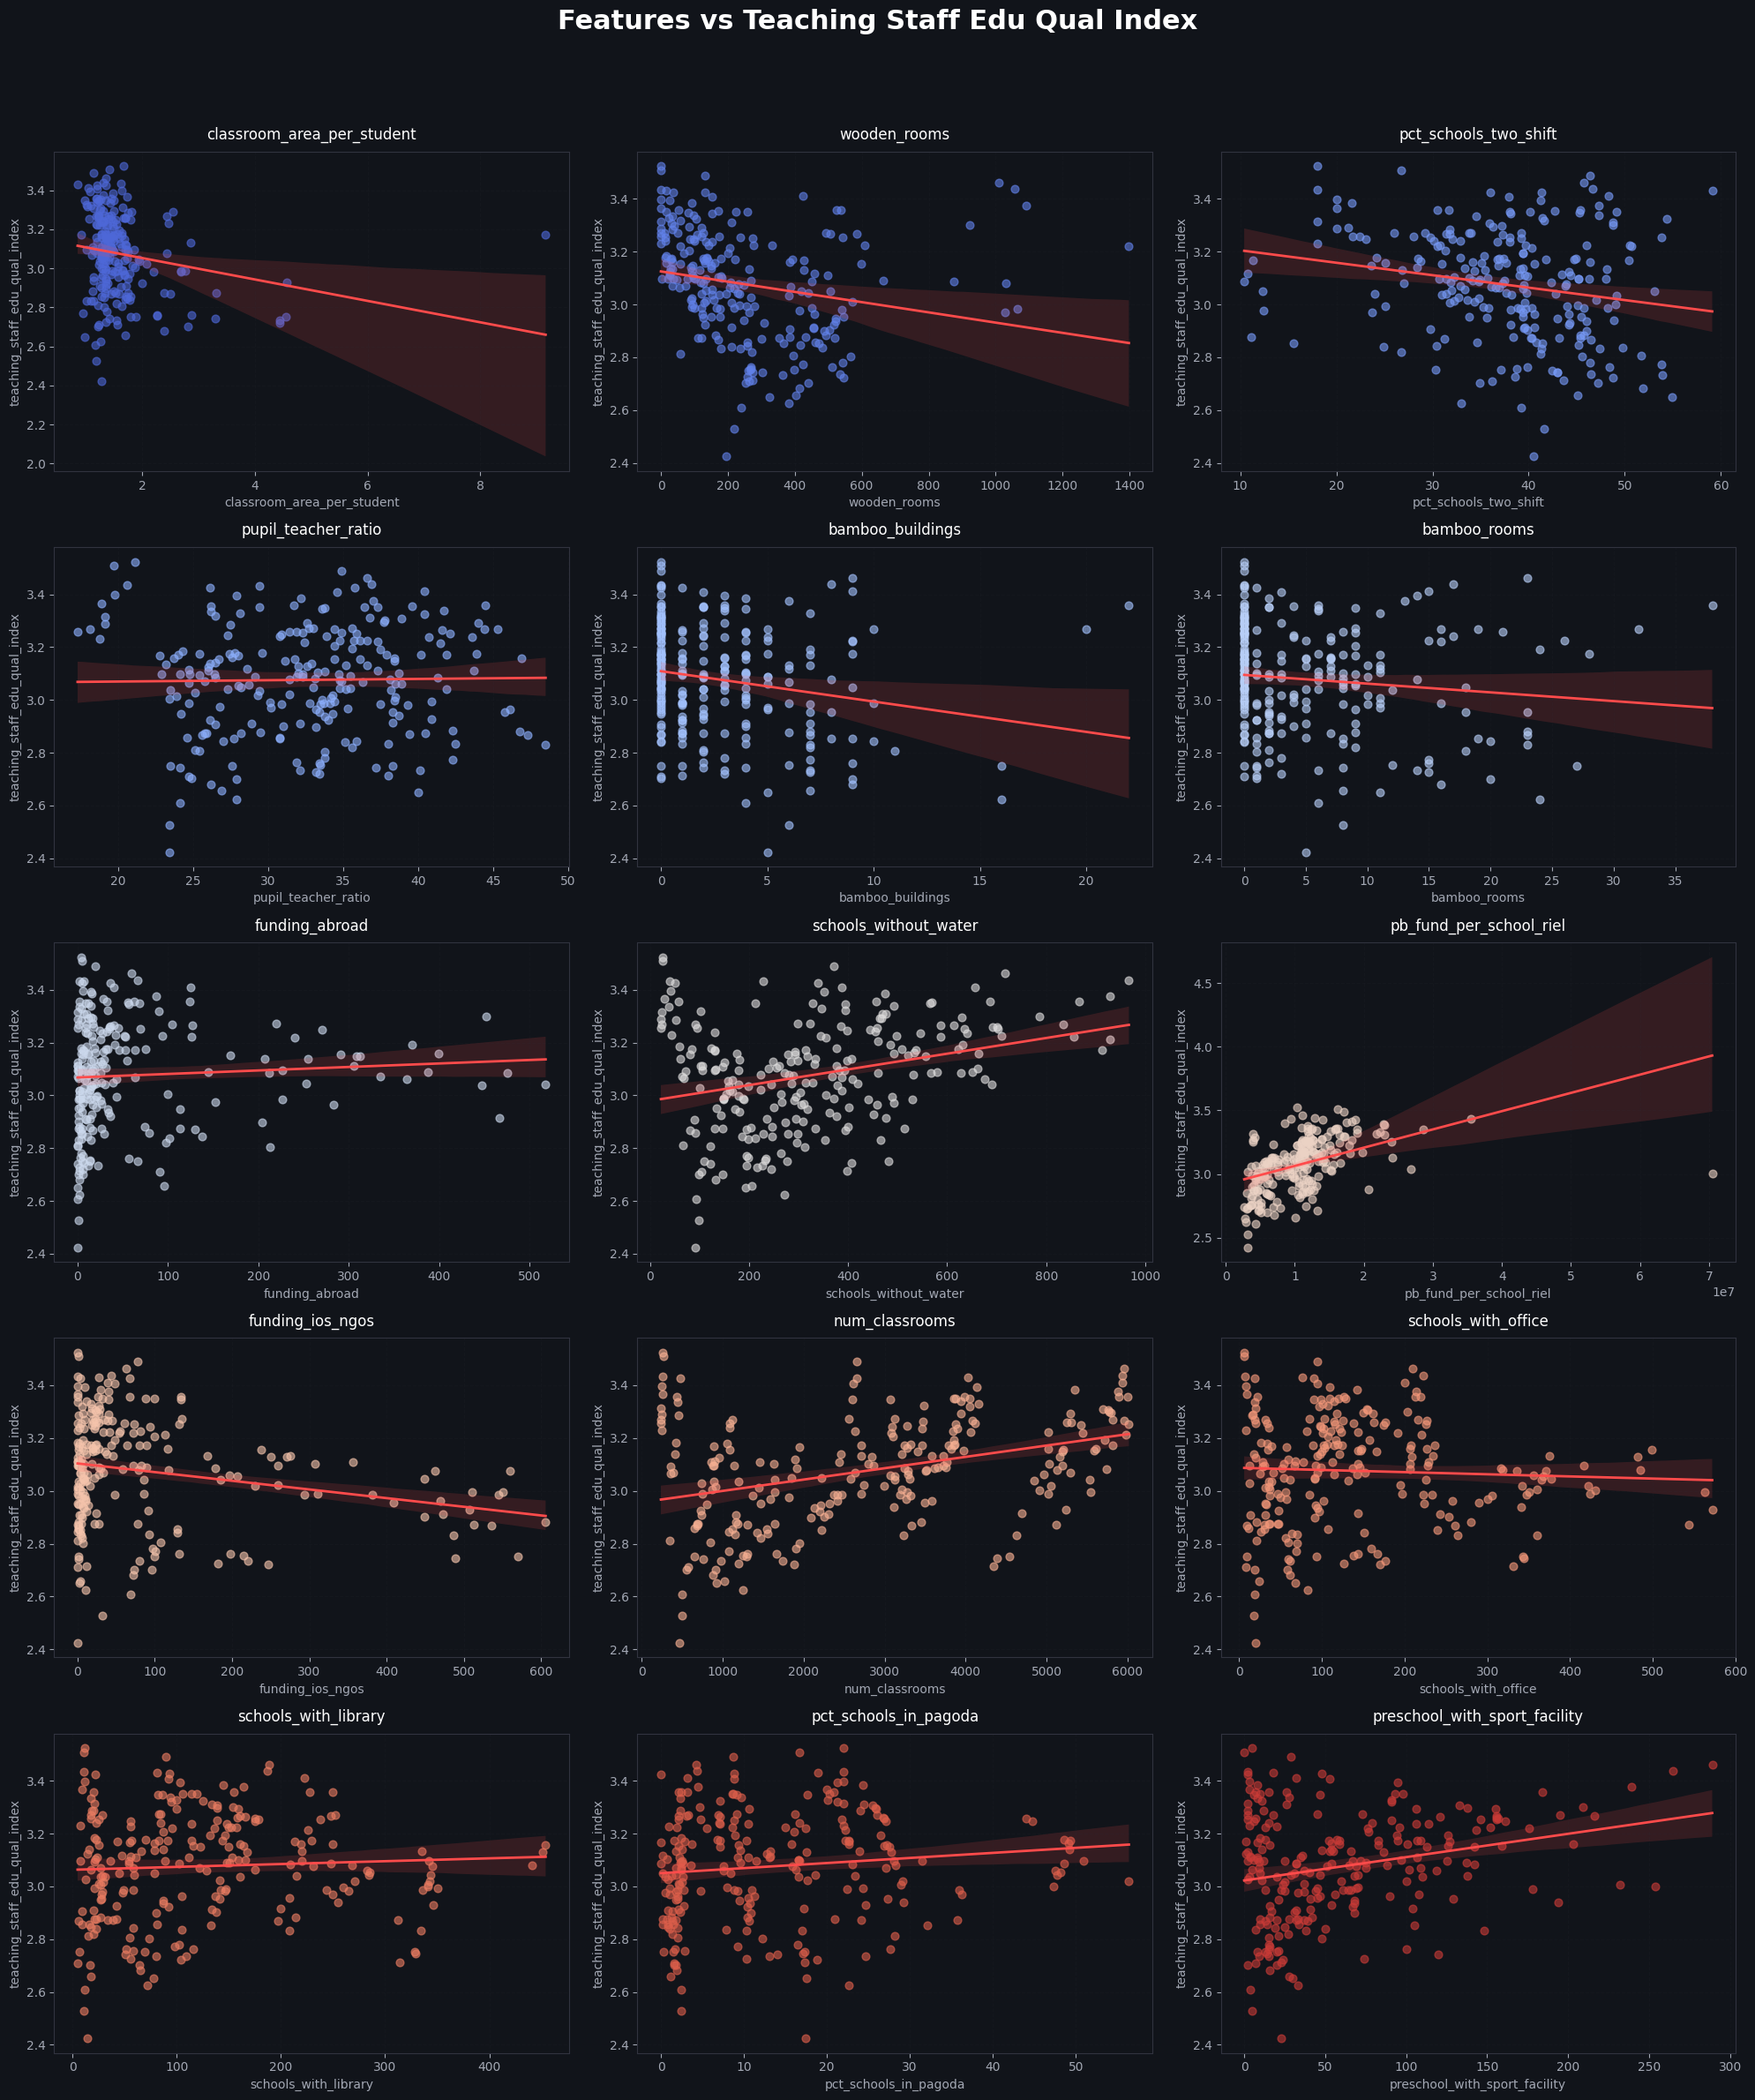

In [ ]:
plot_features_grid(teacher,feature3,"teaching_staff_edu_qual_index")

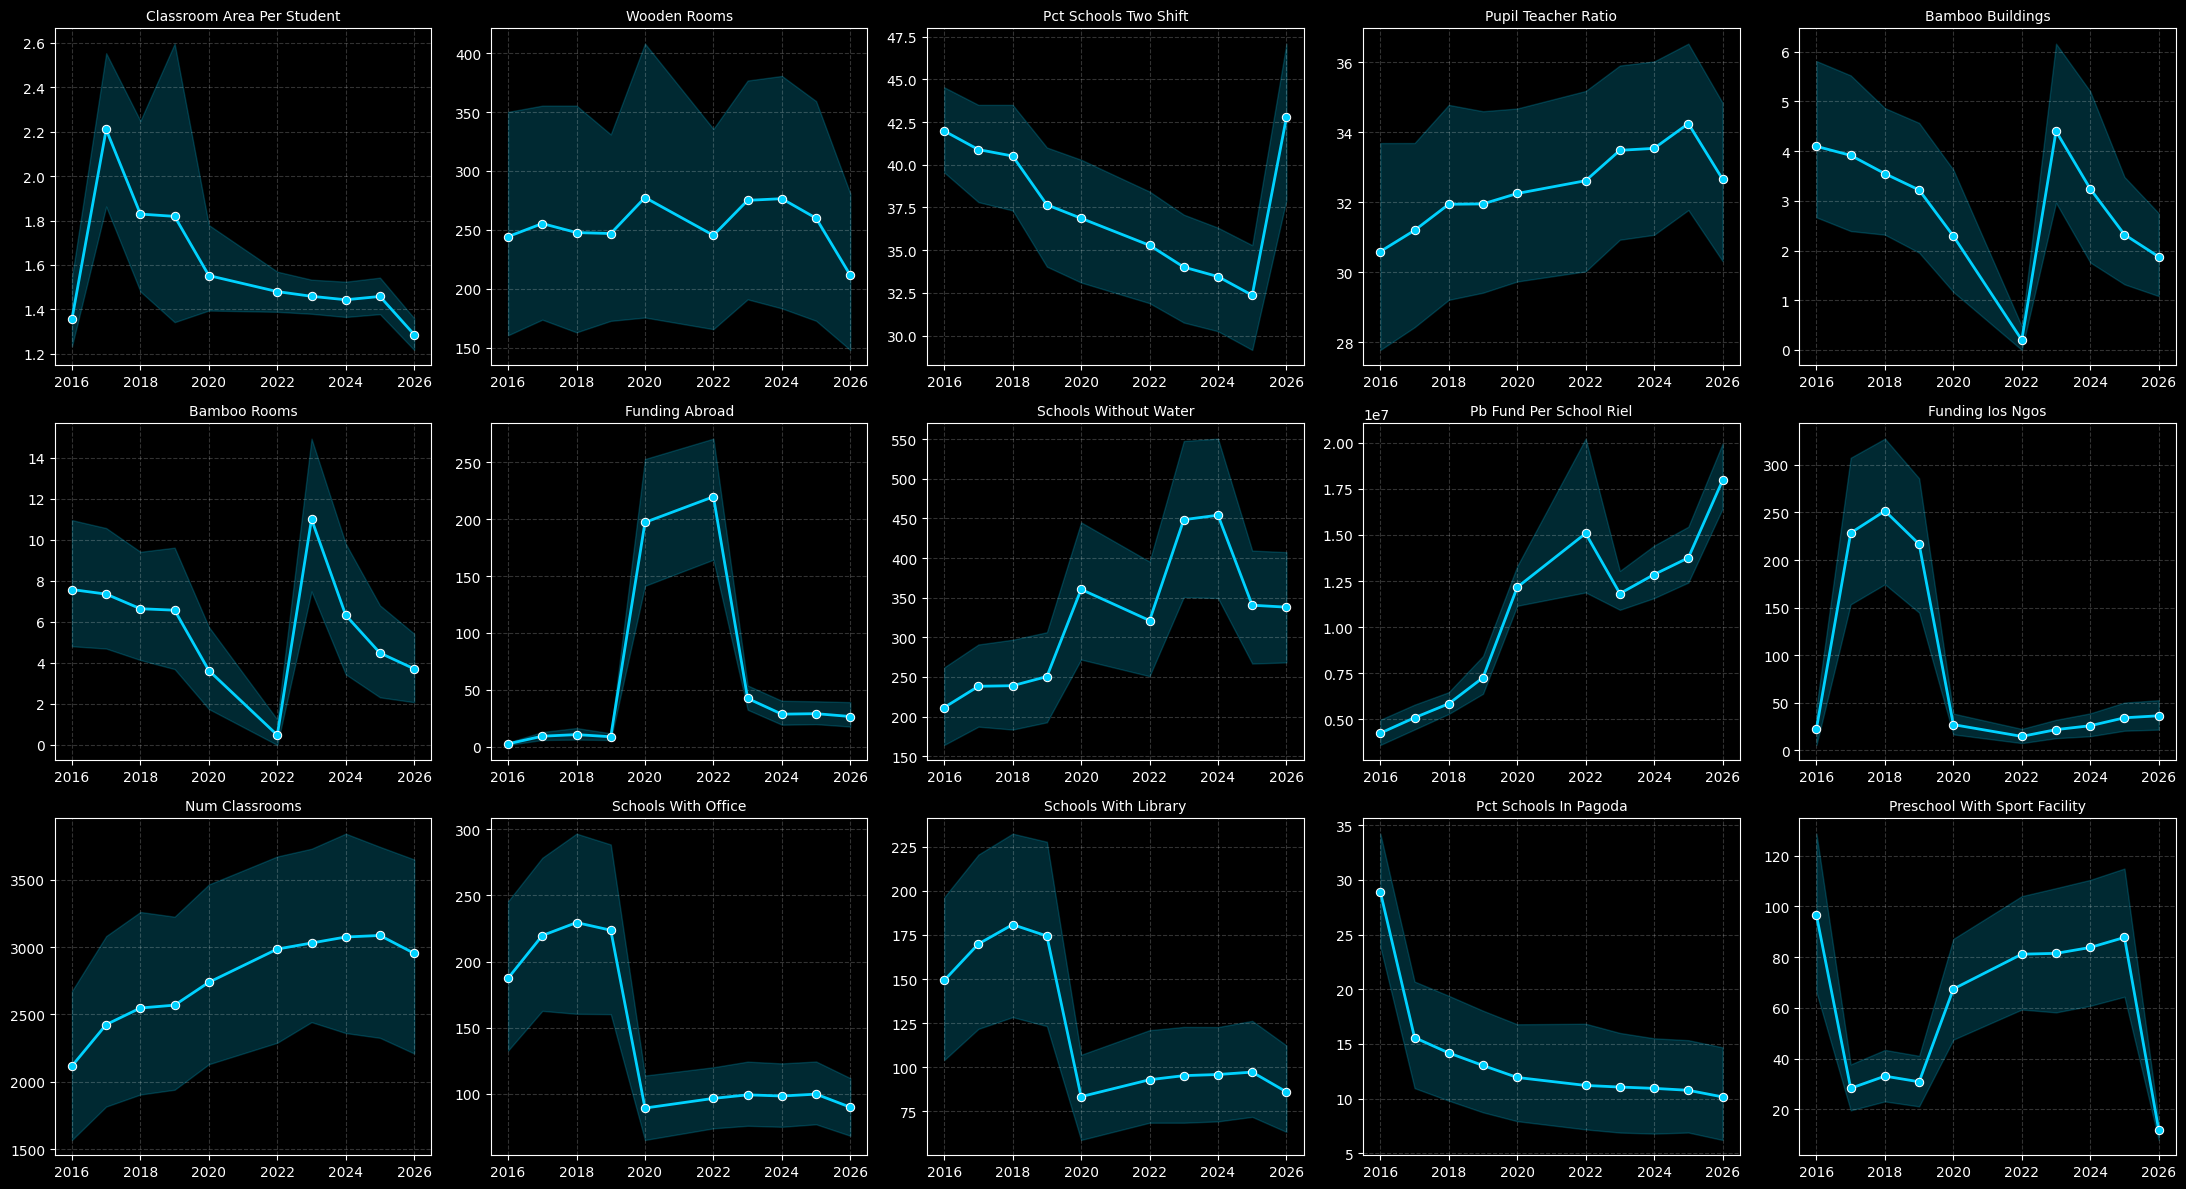

In [ ]:
plot_timeseries_grid(teacher,feature3)